## Iterative Imputer

1. Định nghĩa
- Iterative Imputer hay MICE (Multivariate Imputation by Chained Equations) là một phương pháp để gán dữ liệu đa biến bằng cách chỉ định mô hình gán riêng biệt cho từng biến dựa trên một tập hợp các mật độ có điều kiện (conditional densities)
- Quá trình này được thực hiện theo một vòng lặp tuần hoàn (iterative): tại mỗi bước, một đặc trưng được chọn làm biến mục tiêu (target) và các đặc trưng còn lại đóng vai trò là biến độc lập (predictors). Các giá trị thiếu sẽ được dự đoán thông qua một mô hình hồi quy (hoặc phân loại) và được cập nhật liên tục qua nhiều vòng lặp cho đến khi các giá trị dự đoán đạt đến trạng thái hội tụ ổn định.
- Sự linh hoạt: MICE là một giải pháp thay thế cho phương pháp mô hình hóa chung (Joint Modeling - JM) trong những trường hợp không thể tìm thấy phân phối đa biến phù hợp cho toàn bộ dữ liệu
2. Phương pháp thực hiện\
a) Khởi tạo: Khởi tạo giá trị thiếu bằng giá trị trung bình, trung vị hoặc 0\
b) Mô hình hóa: Xem các thuộc tính có giá trị thiếu là các biến mục tiêu (target variable), các thuộc tính còn lại là biến độc lập (independent variable), từ đó xây dựng mô hình hồi quy dự đoán các giá trị thiếu.\
c) Gán giá trị thiếu: Gán giá trị thiếu bằng giá trị dự đoán được ở bước 2\
d) Lặp: Lặp lại quá trình từ bước 2 đến khi hội tụ giá trị (theo thể thức Round Robin). Sự hội tụ được định nghĩa khi số lần lặp đạt ngưỡng nhất định (max_iter) hoặc các giá trị là không thay đổi\
3. Dùng thư viện
class sklearn.impute.IterativeImputer(estimator=None, *, missing_values=nan, sample_posterior=False, max_iter=10, tol=0.001, n_nearest_features=None, initial_strategy='mean', fill_value=None, imputation_order='ascending', skip_complete=False, min_value=-inf, max_value=inf, verbose=0, random_state=None, add_indicator=False, keep_empty_features=False)\
Parameters:
- estimator = BayesianRidge() / LinearRegression() / RandomForestRegressor() / ExtraTreesRegressor() / KNeighborsRegressor() / DecisionTreeRegressor(), default = BayesianRidge(), mô hình sử dụng
- missing_values: int or np.nan, default=np.nan, đại diện của missing values
- sample_posterior = True (nếu dùng cho multiple imputations), default = False, phân phối hậu nghiệm
- max_iter: int, default=10, số lần lặp
- tol: float, default=1e-3, điều kiện dừng
- n_nearest_features: int, default=None, số các đặc trưng khác gần nhất (theo hệ số tương quan) dùng để dự đoán missing value, None là dùng hết
- initial_strategy: {‘mean’, ‘median’, ‘most_frequent’, ‘constant’}, default=’mean’, chiến thuật khởi tạo giá trị cho missing values
- fill_value: str or numerical value, default=None, giá trị thay thế cho missing values khi initial_strategy = 'constant'
- imputation_order: {‘ascending’, ‘descending’, ‘roman’, ‘arabic’, ‘random’}, default=’ascending’, thứ tự impute của feature
- random_state: int, RandomState instance or None, default=None, không thay đổi các lựa chọn ngẫu nhiên qua các lần chạy
- add_indicator: bool, default=False, ghi nhớ vị trí từng bị thiếu dữ liệu khi train
- keep_empty_features: bool, default=False, quyết định giữ lại cột trống hoàn toàn
Methods:\
- fit(X, y=None, **fit_params): trả về bộ tham số mô hình
- transform(X): impute tất cả missing value trong tập dữ liệu X
- fit_transform(X, y=None, **params): trả về bộ dữ liệu sau impute
- get_feature_names_out(input_features=None): trả về tên của feature đã chỉnh sửa
- get_params(deep=True): trả về giá trị của tham số
- set_output(*, transform=None), transform = {“default”, “pandas”, “polars”}, default=None, đặt kiểu chứa dữ liệu trả về
- set_params(**params): đặt tham số mô hình

# Run in synthetic dataset

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge
import warnings
warnings.filterwarnings('ignore')
from imputer_tools_mi import missing_imputer


* MCAR

Kích thước dữ liệu: (1000, 3)
Thống kê dữ liệu:



,Age,Education,Income
count,1000.000000,1000.000000,740.000000
mean,44.830000,14.444000,5035.620741
std,14.346809,2.886034,1577.887959
min,20.000000,10.000000,-82.642124
25%,33.000000,12.000000,3923.645396
50%,45.000000,14.000000,5115.515722
75%,56.000000,17.000000,6122.208487
max,69.000000,19.000000,9881.970940


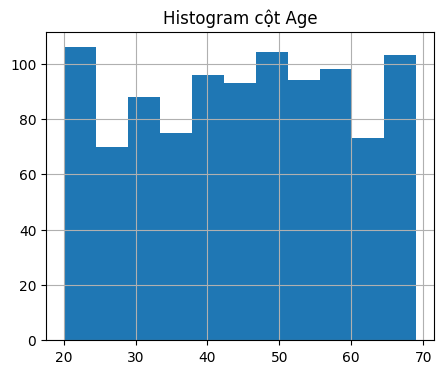

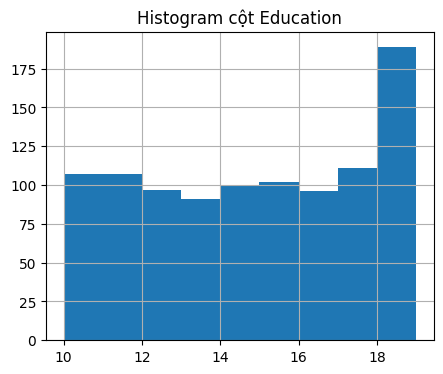

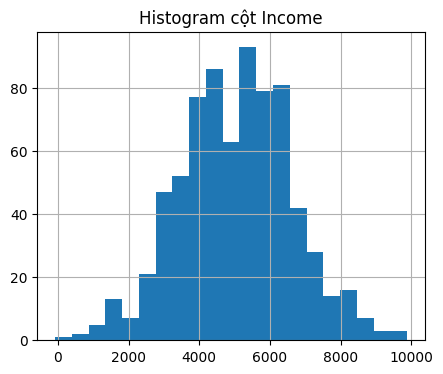

Các cột thiếu: ['Income']


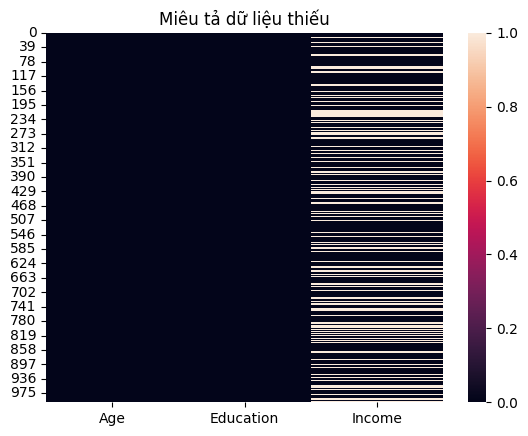

Kết quả:



,Configuration,MSE,MAE
0,MICE-BayesianRidge(max_iter=10),486706.766453,273.389069
3,MICE-BayesianRidge(max_iter=20),486706.766453,273.389069
4,SimpleImputer(mean),486721.832590,273.381582
1,MICE-RandomForest(max_iter=10),681884.627558,346.615294
2,MICE-ExtraTrees(max_iter=10),787595.762533,374.175717
5,KNNImputer,930664.108040,404.174521


In [20]:
mcar = pd.read_csv('../data/synthetic data/MCAR/dataset_missing.csv')
org_mcar = pd.read_csv('../data/synthetic data/MCAR/dataset_goc.csv')
print(f"Kích thước dữ liệu: {mcar.shape}")
print("Thống kê dữ liệu:\n")
display(mcar.describe())

# Phân phối dữ liệu
for col in mcar.columns:
    plt.figure(figsize=(5,4))
    mcar[col].hist(bins='auto')
    plt.title(f'Histogram cột {col}')
    plt.show()

# Lấy cột có missing values
missing_cols = mcar.columns[mcar.isna().any()].tolist()
print(f"Các cột thiếu: {missing_cols}")

# Heatmap giá trị thiếu
plt.figure()
sns.heatmap(mcar.isnull())
plt.title('Miêu tả dữ liệu thiếu')
plt.show()

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
clf = RandomForestClassifier(n_estimators=200, random_state=7)

all_imputers = {
    # IterativeImputer – 4 configurations
    'MICE-BayesianRidge(max_iter=10)':  IterativeImputer(estimator=BayesianRidge(),
                                           max_iter=10, random_state=0),
    'MICE-RandomForest(max_iter=10)':   IterativeImputer(estimator=RandomForestRegressor(50,random_state=0),
                                           max_iter=10, random_state=0),
    'MICE-ExtraTrees(max_iter=10)':     IterativeImputer(estimator=ExtraTreesRegressor(50,random_state=0),
                                           max_iter=10, random_state=0),
    'MICE-BayesianRidge(max_iter=20)':  IterativeImputer(estimator=BayesianRidge(),
                                           max_iter=20, random_state=0),
    'SimpleImputer(mean)': SimpleImputer(strategy='mean'),
    'KNNImputer': KNNImputer(n_neighbors=5, weights='distance')
}

# Split train-test
train_idx, test_idx = train_test_split(range(len(mcar)),test_size=0.2, shuffle=True, random_state=42)

# Reset index NGOÀI vòng lặp, lưu bản gốc
X_train_raw = mcar.iloc[train_idx].reset_index(drop=True)
X_test_raw  = mcar.iloc[test_idx].reset_index(drop=True)
X_test_org  = org_mcar.iloc[test_idx].reset_index(drop=True)

results = []
for config, imp in all_imputers.items():
    # Copy lại mỗi vòng, tránh ghi đè
    X_train = X_train_raw.copy()
    X_test  = X_test_raw.copy()

    missing_mask_train = X_train.isna()
    missing_mask_test  = X_test.isna()

    train_mean      = X_train.mean()
    X_train_filled  = X_train.fillna(train_mean)
    X_test_filled   = X_test.fillna(train_mean)

    scaler = StandardScaler()
    scaler.fit(X_train_filled)

    X_train_scaled = pd.DataFrame(scaler.transform(X_train_filled), columns=X_train.columns)
    X_test_scaled  = pd.DataFrame(scaler.transform(X_test_filled),  columns=X_test.columns)

    # Index đã khớp, gán NaN đúng vị trí
    X_train_scaled[missing_mask_train] = np.nan
    X_test_scaled[missing_mask_test]   = np.nan

    imp.fit(X_train_scaled)
    data_out = pd.DataFrame(imp.transform(X_test_scaled), columns=X_test_scaled.columns)
    # Trả về scale gốc trước khi so sánh
    data_original_scale = pd.DataFrame(
        scaler.inverse_transform(data_out), columns=X_test.columns
    )

    results.append({
        'Configuration': config,
        'MSE': mean_squared_error(X_test_org[missing_cols], data_original_scale[missing_cols]),
        'MAE': mean_absolute_error(X_test_org[missing_cols], data_original_scale[missing_cols]),
    })

results = pd.DataFrame(results)

print("Kết quả:\n")
results = pd.DataFrame(results)
display(results.sort_values(['MSE', 'MAE']))

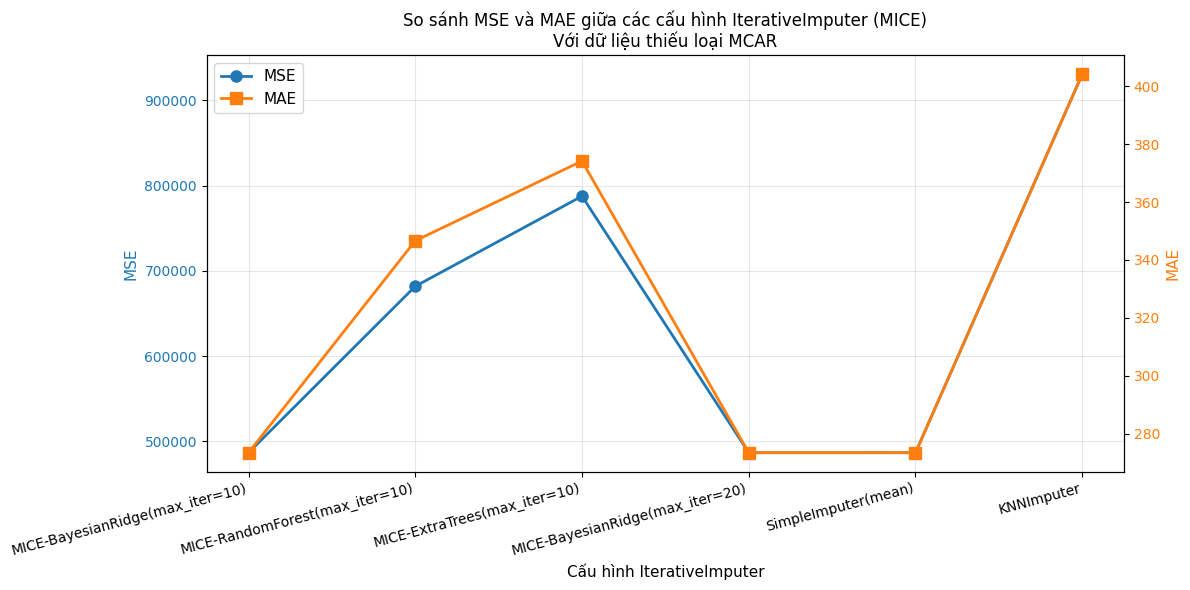

In [21]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = results['Configuration']
y_mse = results['MSE']
y_mae = results['MAE']
x_pos = range(len(x))

# Trục Y trái cho MSE
ax1.plot(x_pos, y_mse, label="MSE", marker='o', linewidth=2, markersize=8, color='#1f77b4')
ax1.set_xlabel("Cấu hình IterativeImputer", fontsize=11)
ax1.set_ylabel("MSE", fontsize=11, color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(True, alpha=0.3)

# Trục Y phải cho MAE
ax2 = ax1.twinx()
ax2.plot(x_pos, y_mae, label="MAE", marker='s', linewidth=2, markersize=8, color='#ff7f0e')
ax2.set_ylabel("MAE", fontsize=11, color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

plt.title("So sánh MSE và MAE giữa các cấu hình IterativeImputer (MICE)\nVới dữ liệu thiếu loại MCAR", fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x, rotation=15, ha='right', fontsize=10)

# Hợp nhất legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11)

plt.tight_layout()
plt.show()

* Kết luận với bộ dữ liệu giả lập trên:\
=> Cấu hình BayesianRidge có sai số nhỏ nhất và hiệu suất tốt nhất khi impute cho bộ dataset trên.

* MNAR

Kích thước dữ liệu: (1000, 3)
Thống kê dữ liệu:



,Age,Education,Income
count,1000.000000,1000.000000,83.000000
mean,44.830000,14.444000,3451.870289
std,14.346809,2.886034,1515.510276
min,20.000000,10.000000,-82.642124
25%,33.000000,12.000000,2336.569279
50%,45.000000,14.000000,3310.179782
75%,56.000000,17.000000,4546.312890
max,69.000000,19.000000,6285.637995


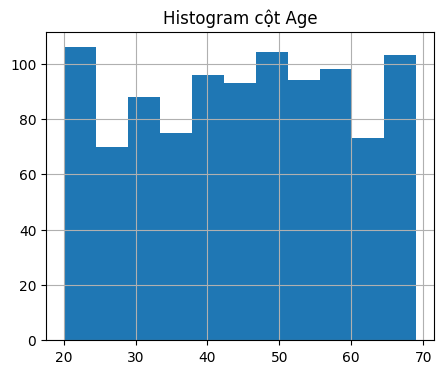

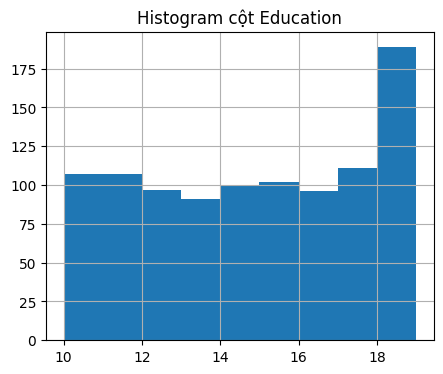

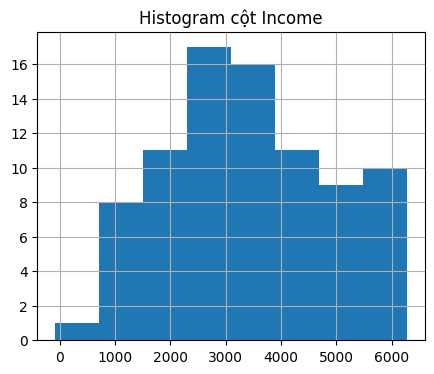

Các cột thiếu: ['Income']


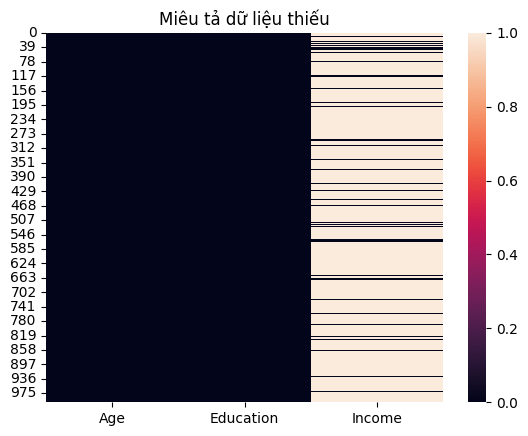

Kết quả:



,Configuration,MSE,MAE
4,SimpleImputer(mean),4.206453e+06,1633.532671
0,MICE-BayesianRidge(max_iter=10),4.240884e+06,1641.318735
3,MICE-BayesianRidge(max_iter=20),4.240884e+06,1641.318735
5,KNNImputer,5.089896e+06,1755.631396
1,MICE-RandomForest(max_iter=10),5.104799e+06,1774.355571
2,MICE-ExtraTrees(max_iter=10),5.874491e+06,1876.920546


In [22]:
mnar = pd.read_csv('../data/synthetic data/MNAR/dataset_missing.csv')
org_mnar = pd.read_csv('../data/synthetic data/MNAR/dataset_goc.csv')
print(f"Kích thước dữ liệu: {mnar.shape}")
print("Thống kê dữ liệu:\n")
display(mnar.describe())

# Phân phối dữ liệu
for col in mnar.columns:
    plt.figure(figsize=(5,4))
    mnar[col].hist(bins='auto')
    plt.title(f'Histogram cột {col}')
    plt.show()

# Lấy cột có missing values
missing_cols = mnar.columns[mnar.isna().any()].tolist()
print(f"Các cột thiếu: {missing_cols}")

# Heatmap giá trị thiếu
plt.figure()
sns.heatmap(mnar.isnull())
plt.title('Miêu tả dữ liệu thiếu')
plt.show()

# Split train-test
train_idx, test_idx = train_test_split(range(len(mnar)),test_size=0.2, shuffle=True, random_state=42)

# Reset index NGOÀI vòng lặp, lưu bản gốc
X_train_raw = mnar.iloc[train_idx].reset_index(drop=True)
X_test_raw  = mnar.iloc[test_idx].reset_index(drop=True)
X_test_org  = org_mnar.iloc[test_idx].reset_index(drop=True)

mnar_results = []
for config, imp in all_imputers.items():
    # Copy lại mỗi vòng, tránh ghi đè
    X_train = X_train_raw.copy()
    X_test  = X_test_raw.copy()

    missing_mask_train = X_train.isna()
    missing_mask_test  = X_test.isna()

    train_mean      = X_train.mean()
    X_train_filled  = X_train.fillna(train_mean)
    X_test_filled   = X_test.fillna(train_mean)

    scaler = StandardScaler()
    scaler.fit(X_train_filled)

    X_train_scaled = pd.DataFrame(scaler.transform(X_train_filled), columns=X_train.columns)
    X_test_scaled  = pd.DataFrame(scaler.transform(X_test_filled),  columns=X_test.columns)

    # Index đã khớp, gán NaN đúng vị trí
    X_train_scaled[missing_mask_train] = np.nan
    X_test_scaled[missing_mask_test]   = np.nan

    imp.fit(X_train_scaled)
    data_out = pd.DataFrame(imp.transform(X_test_scaled), columns=X_test_scaled.columns)
    # Trả về scale gốc trước khi so sánh
    data_original_scale = pd.DataFrame(
        scaler.inverse_transform(data_out), columns=X_test.columns
    )

    mnar_results.append({
        'Configuration': config,
        'MSE': mean_squared_error(X_test_org[missing_cols], data_original_scale[missing_cols]),
        'MAE': mean_absolute_error(X_test_org[missing_cols], data_original_scale[missing_cols]),
    })

print("Kết quả:\n")
mnar_results = pd.DataFrame(mnar_results)
display(mnar_results.sort_values(['MSE', 'MAE']))

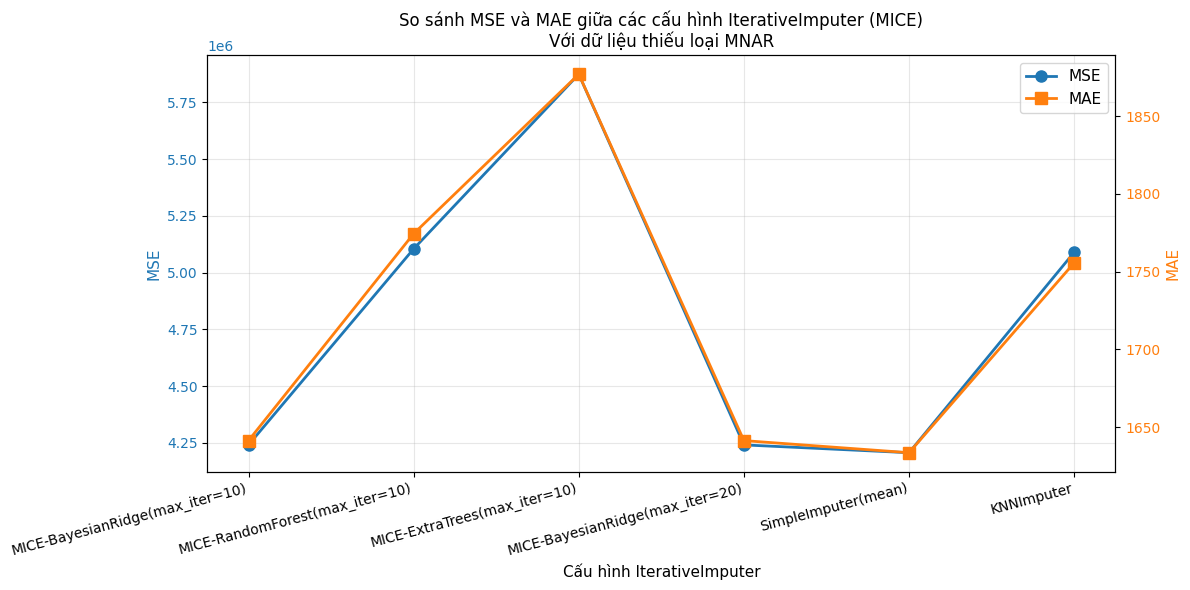

In [23]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = mnar_results['Configuration']
y_mse = mnar_results['MSE']
y_mae = mnar_results['MAE']
x_pos = range(len(x))

# Trục Y trái cho MSE
ax1.plot(x_pos, y_mse, label="MSE", marker='o', linewidth=2, markersize=8, color='#1f77b4')
ax1.set_xlabel("Cấu hình IterativeImputer", fontsize=11)
ax1.set_ylabel("MSE", fontsize=11, color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(True, alpha=0.3)

# Trục Y phải cho MAE
ax2 = ax1.twinx()
ax2.plot(x_pos, y_mae, label="MAE", marker='s', linewidth=2, markersize=8, color='#ff7f0e')
ax2.set_ylabel("MAE", fontsize=11, color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

plt.title("So sánh MSE và MAE giữa các cấu hình IterativeImputer (MICE)\nVới dữ liệu thiếu loại MNAR", fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x, rotation=15, ha='right', fontsize=10)

# Hợp nhất legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11)

plt.tight_layout()
plt.show()

* Kết luận:\
=> Cấu hình BayesianRidge vẫn đạt được hiệu suất tốt hơn các cấu hình khác, tuy nhiên sai số chung vẫn lớn hơn so với khi triển khai trên dữ liệu thiếu MCAR, do tính phức tạp trong quan hệ của dữ liệu thiếu.

* Dataset kết hợp

,Age,Education,Income,Experience
0,58.0,18.0,6214.957431,10.0
1,48.0,NaN,4380.284251,14.0
2,34.0,14.0,4786.980575,31.0
3,62.0,NaN,5580.463217,27.0
4,27.0,14.0,4358.274699,21.0


Kích thước dữ liệu: (1000, 4)
Thống kê dữ liệu:



,Age,Education,Income,Experience
count,840.000000,668.000000,713.000000,898.000000
mean,44.508333,14.519461,5122.014489,19.465479
std,14.322688,2.897744,867.874885,11.514492
min,20.000000,10.000000,2855.142225,0.000000
25%,32.750000,12.000000,4488.420183,10.000000
50%,45.000000,15.000000,5178.049607,19.500000
75%,56.000000,17.000000,5727.712890,29.000000
max,69.000000,19.000000,7517.481470,39.000000


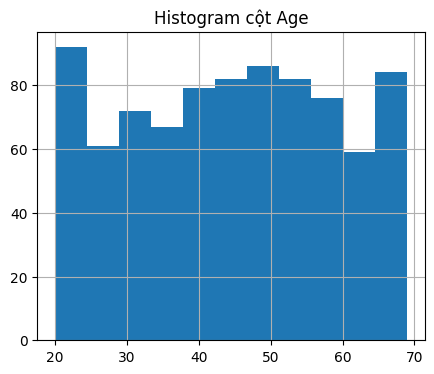

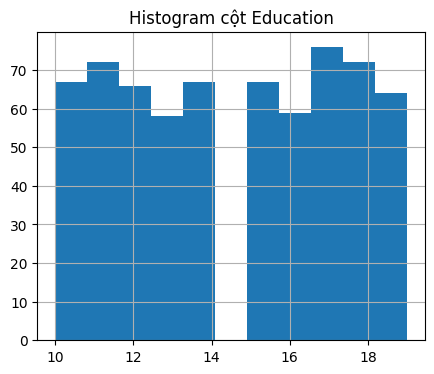

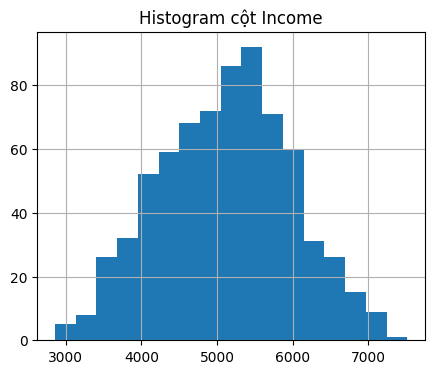

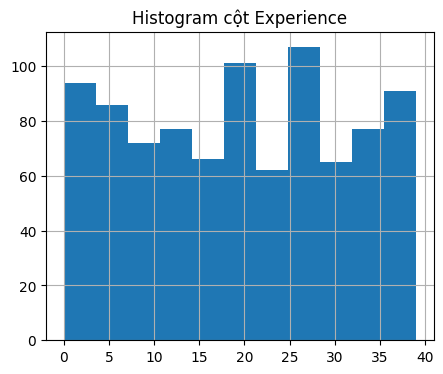

Các cột thiếu: ['Age', 'Education', 'Income', 'Experience']


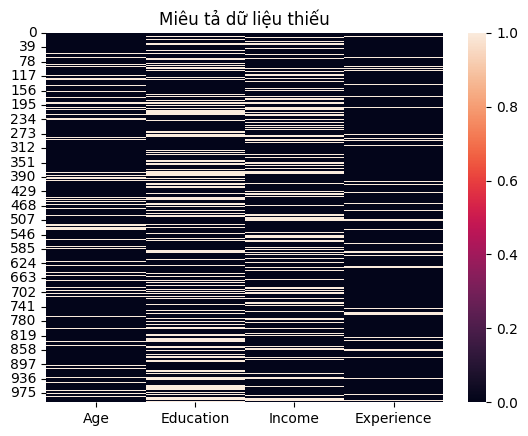

Kết quả:



,Configuration,MSE,MAE
0,MICE-BayesianRidge(max_iter=10),25333.685043,31.727583
3,MICE-BayesianRidge(max_iter=20),25333.685043,31.727583
1,MICE-RandomForest(max_iter=10),27147.948886,32.717701
2,MICE-ExtraTrees(max_iter=10),39174.706606,39.667592
5,KNNImputer,61150.698151,52.072536
4,SimpleImputer(mean),62798.819683,51.947744


In [24]:
combined = pd.read_csv('../data/synthetic data/ket_hop/dataset_missing.csv')
org_combined = pd.read_csv('../data/synthetic data/ket_hop/dataset_goc.csv')
display(combined.head())
print(f"Kích thước dữ liệu: {combined.shape}")
print("Thống kê dữ liệu:\n")
display(combined.describe())

# Phân phối dữ liệu
for col in combined.columns:
    plt.figure(figsize=(5,4))
    combined[col].hist(bins='auto')
    plt.title(f'Histogram cột {col}')
    plt.show()

# Lấy cột có missing values
missing_cols = combined.columns[combined.isna().any()].tolist()
print(f"Các cột thiếu: {missing_cols}")

# Heatmap giá trị thiếu
plt.figure()
sns.heatmap(combined.isnull())
plt.title('Miêu tả dữ liệu thiếu')
plt.show()

# Split train-test
train_idx, test_idx = train_test_split(range(len(combined)),test_size=0.2, shuffle=True, random_state=42)

# Reset index NGOÀI vòng lặp, lưu bản gốc
X_train_raw = combined.iloc[train_idx].reset_index(drop=True)
X_test_raw  = combined.iloc[test_idx].reset_index(drop=True)
X_test_org  = org_combined.iloc[test_idx].reset_index(drop=True)

combined_results = []
for config, imp in all_imputers.items():
    # Copy lại mỗi vòng, tránh ghi đè
    X_train = X_train_raw.copy()
    X_test  = X_test_raw.copy()

    missing_mask_train = X_train.isna()
    missing_mask_test  = X_test.isna()

    train_mean      = X_train.mean()
    X_train_filled  = X_train.fillna(train_mean)
    X_test_filled   = X_test.fillna(train_mean)

    scaler = StandardScaler()
    scaler.fit(X_train_filled)

    X_train_scaled = pd.DataFrame(scaler.transform(X_train_filled), columns=X_train.columns)
    X_test_scaled  = pd.DataFrame(scaler.transform(X_test_filled),  columns=X_test.columns)

    # Index đã khớp, gán NaN đúng vị trí
    X_train_scaled[missing_mask_train] = np.nan
    X_test_scaled[missing_mask_test]   = np.nan

    imp.fit(X_train_scaled)
    data_out = pd.DataFrame(imp.transform(X_test_scaled), columns=X_test_scaled.columns)
    # Trả về scale gốc trước khi so sánh
    data_original_scale = pd.DataFrame(
        scaler.inverse_transform(data_out), columns=X_test.columns
    )

    combined_results.append({
        'Configuration': config,
        'MSE': mean_squared_error(X_test_org[missing_cols], data_original_scale[missing_cols]),
        'MAE': mean_absolute_error(X_test_org[missing_cols], data_original_scale[missing_cols]),
    })

print("Kết quả:\n")
combined_results = pd.DataFrame(combined_results)
display(combined_results.sort_values(['MSE', 'MAE']))


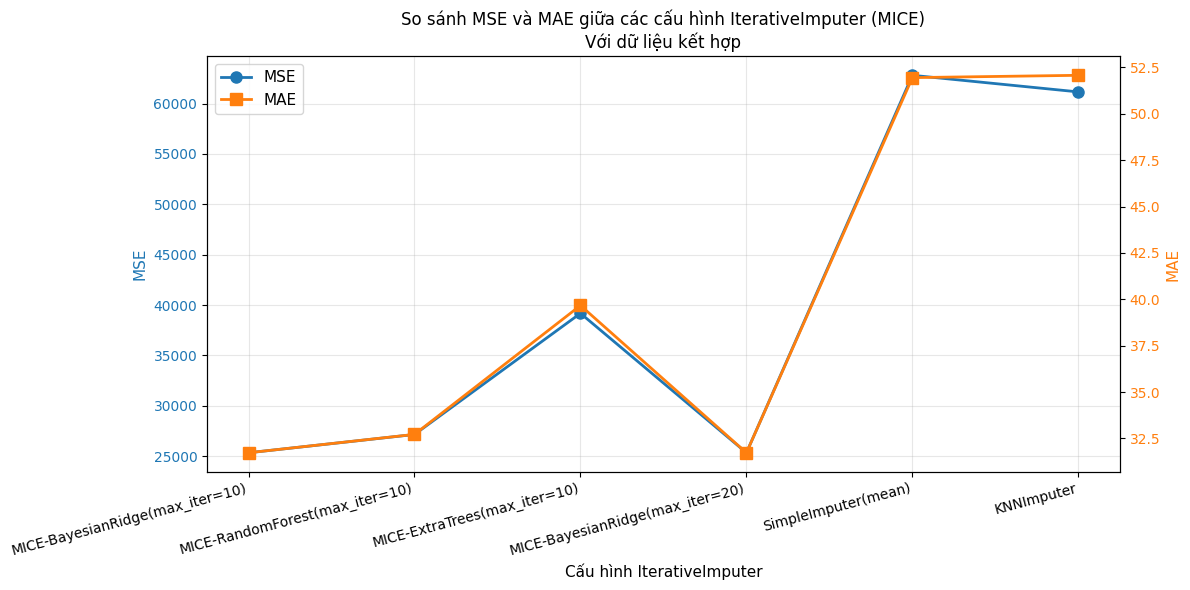

In [25]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = combined_results['Configuration']
y_mse = combined_results['MSE']
y_mae = combined_results['MAE']
x_pos = range(len(x))

# Trục Y trái cho MSE
ax1.plot(x_pos, y_mse, label="MSE", marker='o', linewidth=2, markersize=8, color='#1f77b4')
ax1.set_xlabel("Cấu hình IterativeImputer", fontsize=11)
ax1.set_ylabel("MSE", fontsize=11, color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(True, alpha=0.3)

# Trục Y phải cho MAE
ax2 = ax1.twinx()
ax2.plot(x_pos, y_mae, label="MAE", marker='s', linewidth=2, markersize=8, color='#ff7f0e')
ax2.set_ylabel("MAE", fontsize=11, color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

plt.title("So sánh MSE và MAE giữa các cấu hình IterativeImputer (MICE)\nVới dữ liệu kết hợp", fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x, rotation=15, ha='right', fontsize=10)

# Hợp nhất legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11)

plt.tight_layout()
plt.show()

* Kết luận:\
=> Bayesian vẫn đạt hiệu suất tốt nhất, RandomForest hoạt động tốt trên bộ dữ liệu này, ExtraTrees vẫn có sai số cao nhất

# Run in Realistic Datasets

* Horse Colic

In [26]:
hc_raw = pd.read_csv('../data/real data/horse_colic_train.csv')
display(hc_raw.head())

,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,no,adult,530101,38.5,66.0,28.0,cool,reduced,NaN,more_3_sec,...,45.0,8.4,NaN,NaN,died,no,11300,0,0,no
1,yes,adult,534817,39.2,88.0,20.0,NaN,NaN,pale_cyanotic,less_3_sec,...,50.0,85.0,cloudy,2.0,euthanized,no,2208,0,0,no
2,no,adult,530334,38.3,40.0,24.0,normal,normal,pale_pink,less_3_sec,...,33.0,6.7,NaN,NaN,lived,no,0,0,0,yes
3,yes,young,5290409,39.1,164.0,84.0,cold,normal,dark_cyanotic,more_3_sec,...,48.0,7.2,serosanguious,5.3,died,yes,2208,0,0,yes
4,no,adult,530255,37.3,104.0,35.0,NaN,NaN,dark_cyanotic,more_3_sec,...,74.0,7.4,NaN,NaN,died,no,4300,0,0,no


Kích thước: (299, 58)
Thống kê dữ liệu:



,Unnamed: 0,surgery,age,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,capillary_refill_time,pain,...,nasogastric_reflux_ph_missing,packed_cell_volume_missing,total_protein_missing,abdomo_protein_missing,pain_missing,abdomo_appearance_missing,lesion_site,lesion_type,lesion_subtype,lesion_specific_code
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,243.000000,230.000000,267.000000,299.000000,...,299.000000,299.00000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,149.000000,0.602007,0.919732,30.509365,66.220736,24.551839,1.456790,1.504348,0.292135,1.377926,...,0.822742,0.09699,0.110368,0.662207,0.183946,0.551839,3.505017,1.474916,0.424749,2.953177
std,86.458082,0.490305,0.272162,15.326224,33.741787,19.922496,0.848665,0.603829,0.455598,1.642856,...,0.382527,0.29644,0.313873,0.473750,0.388090,0.498139,5.397844,1.103019,0.652967,3.014141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74.500000,0.000000,1.000000,37.200000,48.000000,12.000000,1.000000,1.000000,0.000000,0.000000,...,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000
50%,149.000000,1.000000,1.000000,38.000000,60.000000,22.000000,1.000000,2.000000,0.000000,1.000000,...,1.000000,0.00000,0.000000,1.000000,0.000000,1.000000,2.000000,1.000000,0.000000,2.000000
75%,223.500000,1.000000,1.000000,38.500000,88.000000,34.500000,2.000000,2.000000,1.000000,3.000000,...,1.000000,0.00000,0.000000,1.000000,0.000000,1.000000,3.000000,2.000000,1.000000,5.000000
max,298.000000,1.000000,1.000000,40.800000,184.000000,96.000000,3.000000,3.000000,1.000000,4.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,41.000000,4.000000,3.000000,9.000000


  rectal_temp: thay 60 giá trị 0 → NaN
  pulse: thay 24 giá trị 0 → NaN
  respiratory_rate: thay 58 giá trị 0 → NaN

Missing values sau tiền xử lý:
rectal_temp               60
pulse                     24
respiratory_rate          58
temp_of_extremities       56
peripheral_pulse          69
capillary_refill_time     32
abdominal_distention      56
nasogastric_tube         104
rectal_exam_feces        102
abdomen                  118
dtype: int64

Phân phối target 'surgical_lesion':
surgical_lesion
1    190
0    109
Name: count, dtype: int64


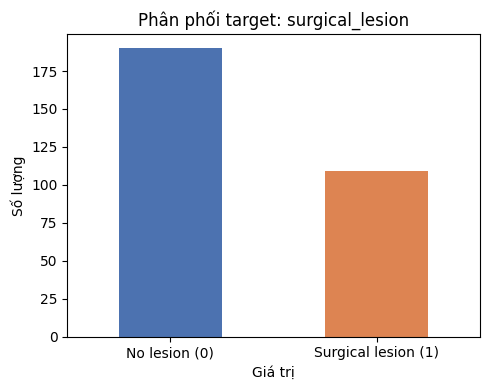

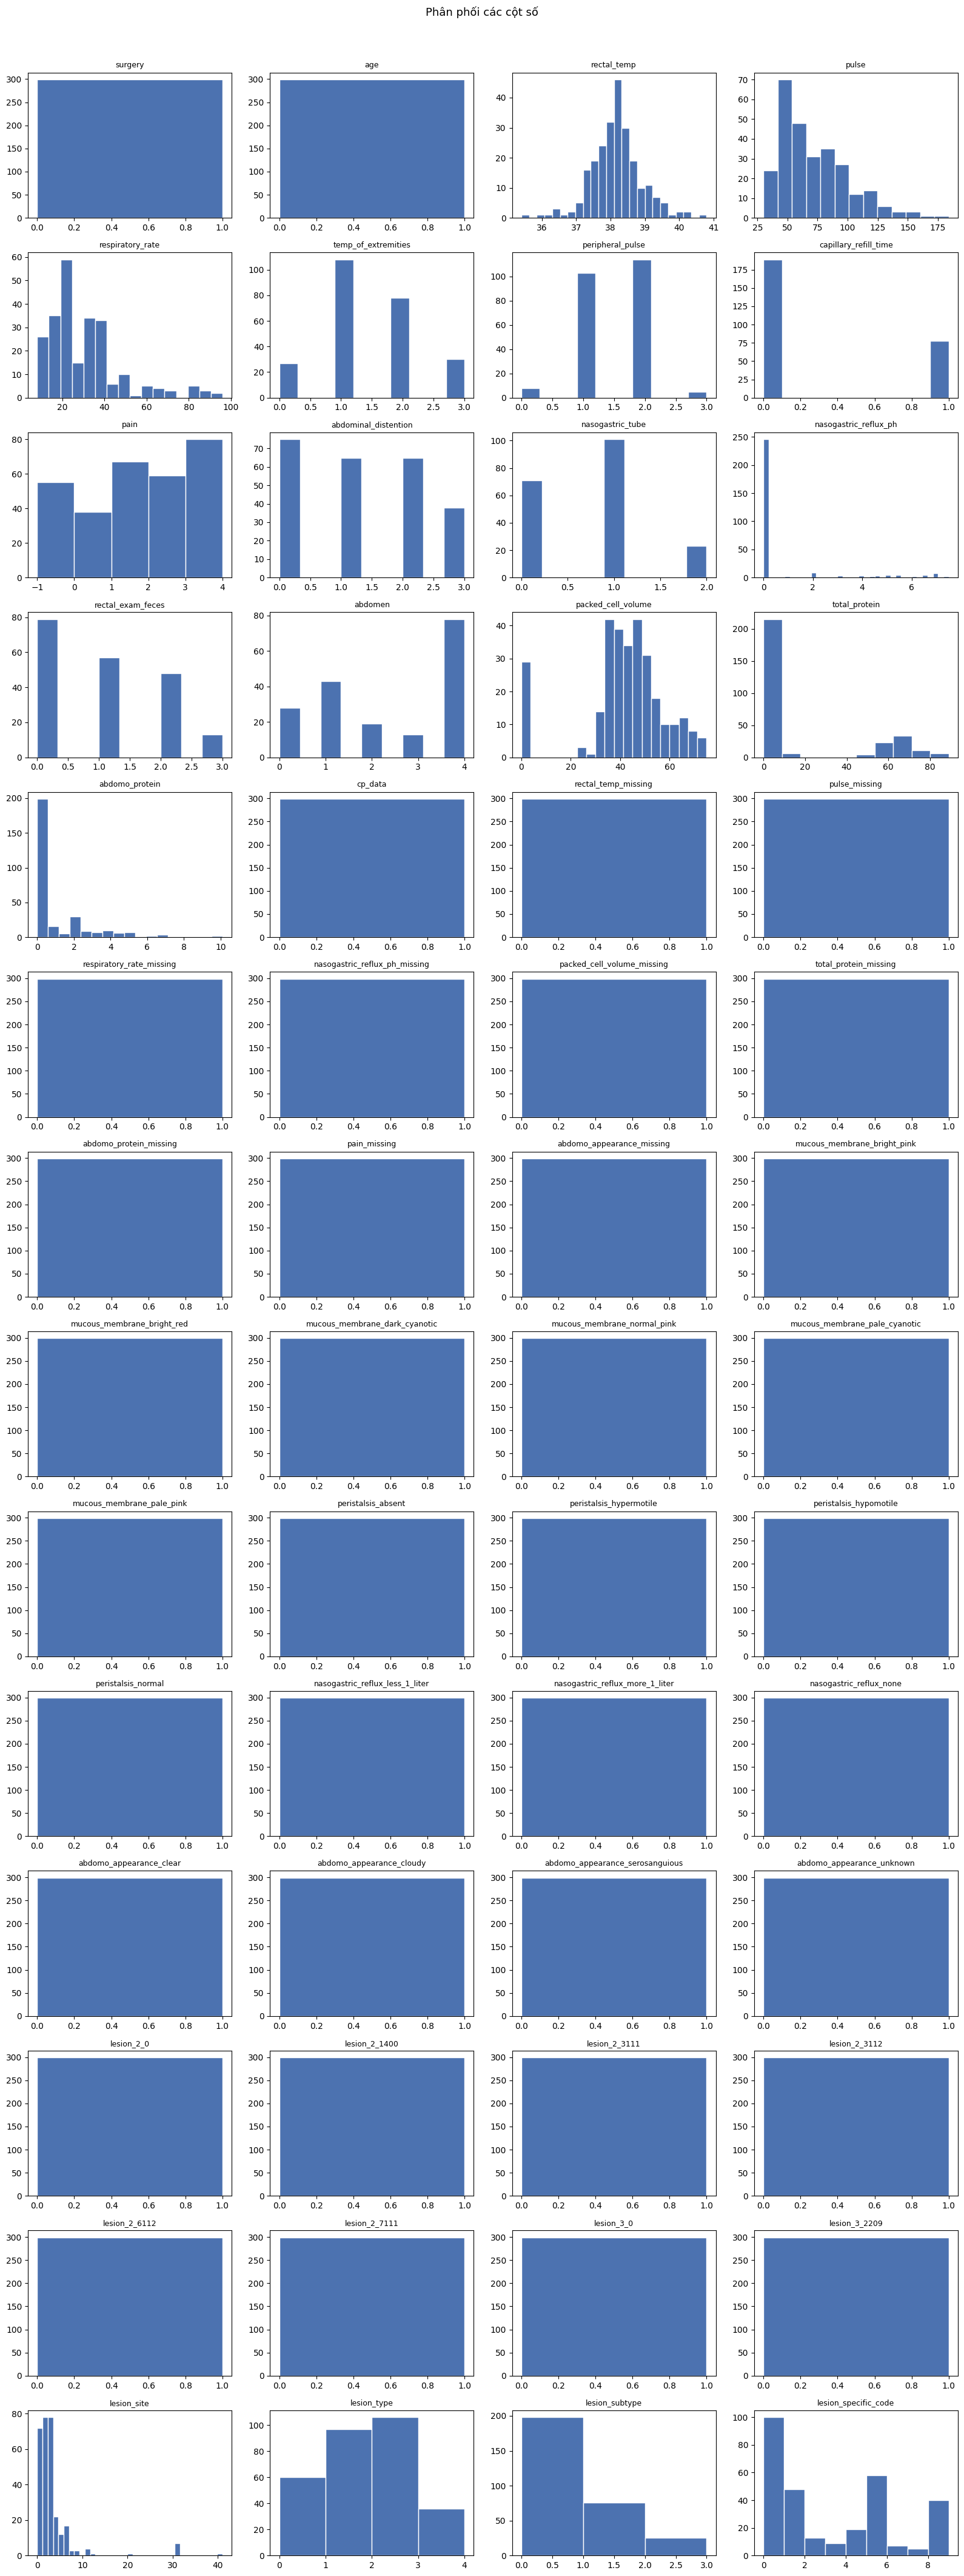

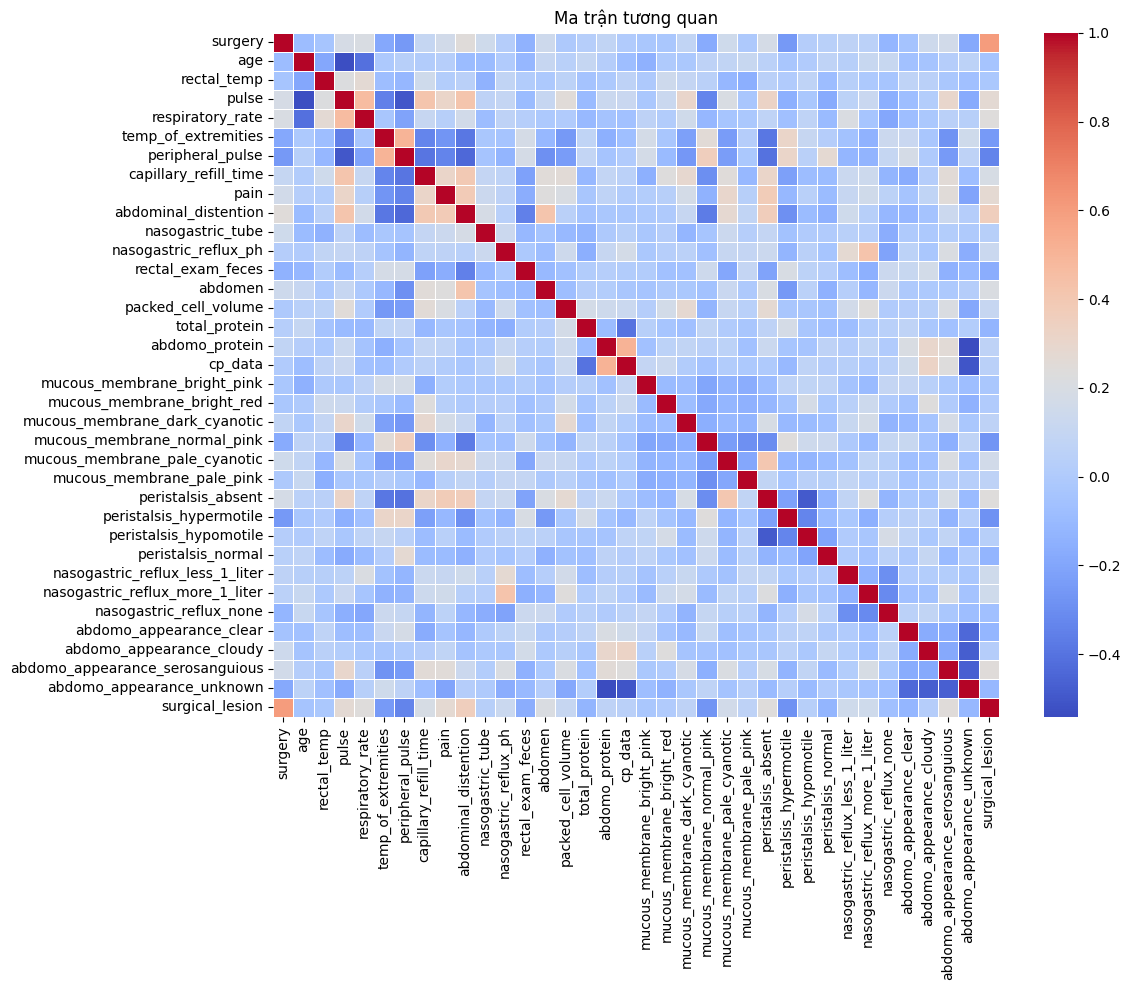

Bảng so sánh sơ bộ (Avg_NRMSE tăng dần)
                        Method name  Avg_NRMSE        F1  Accuracy
0  MICE\nBayesianRidge\nmax_iter=10        NaN  0.363598  0.675424
1   MICE\nRandomForest\nmax_iter=10        NaN  0.384034  0.692203
2     MICE\nExtraTrees\nmax_iter=10        NaN  0.382007  0.685537
3  MICE\nBayesianRidge\nmax_iter=20        NaN  0.363598  0.675424
4               SimpleImputer(mean)        NaN  0.407733  0.695537
5                        KNNImputer        NaN  0.380837  0.675480
6                   Simple\nImputer        NaN  0.407733  0.695537
7                      KNN\nImputer        NaN  0.380837  0.675480


In [27]:
from sklearn.pipeline import Pipeline

hc = pd.read_csv('../data/real data/horse_colic_clean.csv')
print(f"Kích thước: {hc.shape}")
print("Thống kê dữ liệu:\n")
display(hc.describe())

# Drop cột index vô nghĩa
hc = hc.drop(columns=['Unnamed: 0'])
 
# Encode cột string cp_data
hc['cp_data'] = (hc['cp_data'] == 'yes').astype(int)
 
# Encode tất cả cột boolean
bool_cols = hc.select_dtypes('bool').columns.tolist()
hc[bool_cols] = hc[bool_cols].astype(int)
physio_cols = ['rectal_temp', 'pulse', 'respiratory_rate']
for col in physio_cols:
    zeros = (hc[col] == 0).sum()
    print(f"  {col}: thay {zeros} giá trị 0 → NaN")
    hc[col] = hc[col].replace(0, np.nan)
 
print("\nMissing values sau tiền xử lý:")
missing = hc.isna().sum()
print(missing[missing > 0])
 
# ════════════════════════════════════════════
# PHÂN TÍCH KHÁM PHÁ (EDA)
# ════════════════════════════════════════════
 
# Phân phối target
target_col = 'surgical_lesion'
print(f"\nPhân phối target '{target_col}':")
print(hc[target_col].value_counts())
 
plt.figure(figsize=(5, 4))
hc[target_col].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Phân phối target: surgical_lesion')
plt.xlabel('Giá trị')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['No lesion (0)', 'Surgical lesion (1)'], rotation=0)
plt.tight_layout()
plt.show()
 
# Histogram các cột số
num_cols = hc.select_dtypes('number').drop(columns=[target_col]).columns.tolist()
n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(hc[col].dropna(), bins='auto', color='#4C72B0', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Phân phối các cột số', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()
 
# Ma trận tương quan (chỉ cột số, bỏ lesion_* và missing_* indicator)
core_cols = [c for c in num_cols if not c.startswith('lesion_') and not c.endswith('_missing')]
corr = hc[core_cols + [target_col]].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Ma trận tương quan')
plt.tight_layout()
plt.show()
 
# ════════════════════════════════════════════
# TÁCH FEATURES & TARGET, TRAIN-TEST SPLIT
# ════════════════════════════════════════════
X = hc.drop(columns=[target_col])
y = hc[target_col]

# IterativeImputer – 4 configurations
all_imputers = {
    # IterativeImputer – 4 configurations
    'MICE\nBayesianRidge\nmax_iter=10':  IterativeImputer(estimator=BayesianRidge(),
                                           max_iter=10, random_state=0),
    'MICE\nRandomForest\nmax_iter=10':   IterativeImputer(estimator=RandomForestRegressor(n_estimators=50, random_state=0, max_depth=5),
                                           max_iter=5, random_state=0),
    'MICE\nExtraTrees\nmax_iter=10':     IterativeImputer(estimator=ExtraTreesRegressor(50,random_state=0, max_depth=5),
                                           max_iter=5, random_state=0),
    'MICE\nBayesianRidge\nmax_iter=20':  IterativeImputer(estimator=BayesianRidge(),
                                           max_iter=20, random_state=0),
    'SimpleImputer(mean)': SimpleImputer(strategy='mean'),
    'KNNImputer': KNNImputer(n_neighbors=5, weights='distance')
}

# Display offsets of imputed features and orginal features for each configurations
hc_results = []

# IterativeImputer – 4 configurations
for con, imp in all_imputers.items():
    IterI = missing_imputer(df=hc,fold_method= cv,clf_method= clf,imputer_name= con,imputer_method= imp, is_missing=True)
    hc_results.append(IterI)

# Simple Imputer
simp = SimpleImputer(strategy='mean')
SimpI = missing_imputer(df=hc,fold_method= cv,clf_method= clf,imputer_name= 'Simple\nImputer',imputer_method= simp, is_missing=True)
hc_results.append(SimpI)

# KNN Imputer
knn = KNNImputer(n_neighbors=5, weights='distance')
KNNI = missing_imputer(df=hc,fold_method= cv,clf_method= clf,imputer_name= 'KNN\nImputer',imputer_method= knn, is_missing=True)
hc_results.append(KNNI)

hc_results = pd.DataFrame(hc_results)
print('Bảng so sánh sơ bộ (Avg_NRMSE tăng dần)')
print(hc_results.sort_values('Avg_NRMSE'))

*Note: thêm cột NRMSE trung bình (Avg_NRMSE) để tính độ lệch giữa giá trị sau khi điền và giá trị gốc của các cột bị thiếu dữ liệu (Nếu dữ liệu gốc cũng thiếu thì sẽ là NaN) 

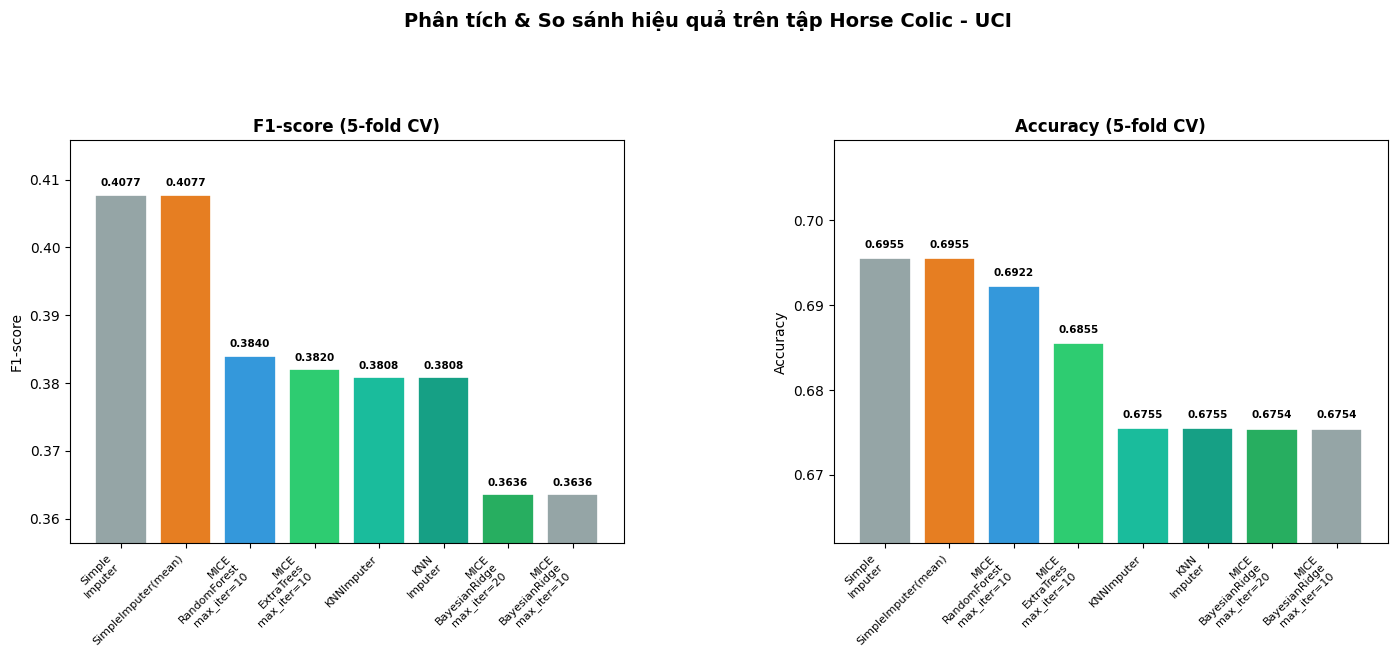

In [31]:
# Bar-charts
hc_results = pd.DataFrame(hc_results).sort_values('F1', ascending=False)
fig = plt.figure(figsize=(17, 13))
fig.suptitle("Phân tích & So sánh hiệu quả trên tập Horse Colic - UCI",
             fontsize=14, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.48, wspace=0.38)

# F1-score
ax1 = fig.add_subplot(gs[0, 0])
all_accs = hc_results['F1']
colors_all = ['#95a5a6','#e67e22','#3498db','#2ecc71','#1abc9c','#16a085','#27ae60']
bars1 = ax1.bar(range(len(hc_results['Method name'])), all_accs,
                color=colors_all, edgecolor='white', linewidth=1.2)

# Thiết lập trục X
ax1.set_xticks(range(len(hc_results['Method name'])))
ax1.set_xticklabels(hc_results['Method name'], fontsize=8, rotation=45, ha='right') # Xoay chữ 45 độ

# Thiết lập giới hạn trục Y cho dễ quan sát sự khác biệt
ax1.set_ylim(min(all_accs)*0.98, max(all_accs)*1.02)

ax1.set_title("F1-score (5-fold CV)", fontweight='bold')
ax1.set_ylabel("F1-score")
for bar, v in zip(bars1, all_accs):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    
# Accuracy
ax2 = fig.add_subplot(gs[0, 1])
all_accs = hc_results['Accuracy']
colors_all = ['#95a5a6','#e67e22','#3498db','#2ecc71','#1abc9c','#16a085','#27ae60']
bars2 = ax2.bar(range(len(hc_results['Method name'])), all_accs,
                color=colors_all, edgecolor='white', linewidth=1.2)

# Thiết lập trục X
ax2.set_xticks(range(len(hc_results['Method name'])))
ax2.set_xticklabels(hc_results['Method name'], fontsize=8, rotation=45, ha='right') # Xoay chữ 45 độ

# Thiết lập giới hạn trục Y cho dễ quan sát sự khác biệt
ax2.set_ylim(min(all_accs)*0.98, max(all_accs)*1.02)

ax2.set_title("Accuracy (5-fold CV)", fontweight='bold')
ax2.set_ylabel("Accuracy")
for bar, v in zip(bars2, all_accs):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

* World bank dataset

Kích thước: (5301, 11)
Thống kê dữ liệu:



,Year,Agri_GDP,Credit_Private,Elec_Access,Emp_Services,FDI_GDP,GDPC_2015,Indus_GDP,Internet_Usage,Serv_GDP
count,5301.000000,5301.000000,5301.000000,5301.000000,5301.000000,5301.000000,5301.000000,5301.000000,5301.000000,5301.000000
mean,2013.991322,10.359460,52.330812,82.201713,53.535482,3.630746,12209.463665,26.278247,43.901066,55.580758
std,6.045669,9.492725,38.650333,25.900926,16.841514,3.500881,14095.360260,10.575754,30.814564,12.091112
min,2004.000000,0.011489,0.000088,22.250000,6.643033,-4.359932,250.878933,2.086302,0.024337,23.562872
25%,2009.000000,2.496275,22.323775,68.900000,40.974711,1.403996,1806.383673,19.249783,14.813300,47.629688
50%,2014.000000,7.302135,43.248875,98.100000,53.598864,2.720599,5508.602656,25.221566,40.440000,54.658291
75%,2019.000000,16.457138,69.990215,100.000000,66.955758,5.246616,17938.094946,32.168275,71.962100,63.674233
max,2024.000000,37.398432,141.489874,100.000000,93.678238,11.010544,42135.661855,51.546014,100.000000,87.741049



Phân phối target 'Serv_GDP':
Serv_GDP
87.741049    62
23.562872    23
38.636645    14
56.550451    13
54.658163    13
             ..
34.974950     1
37.678032     1
28.660657     1
49.563454     1
50.605296     1
Name: count, Length: 4946, dtype: int64


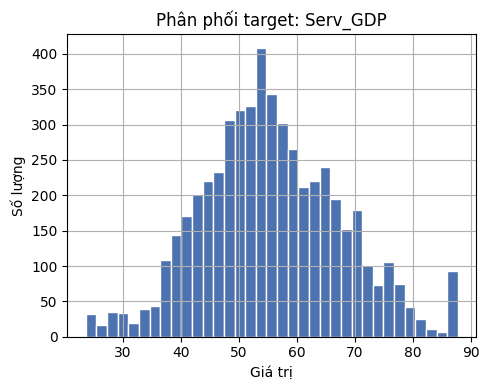

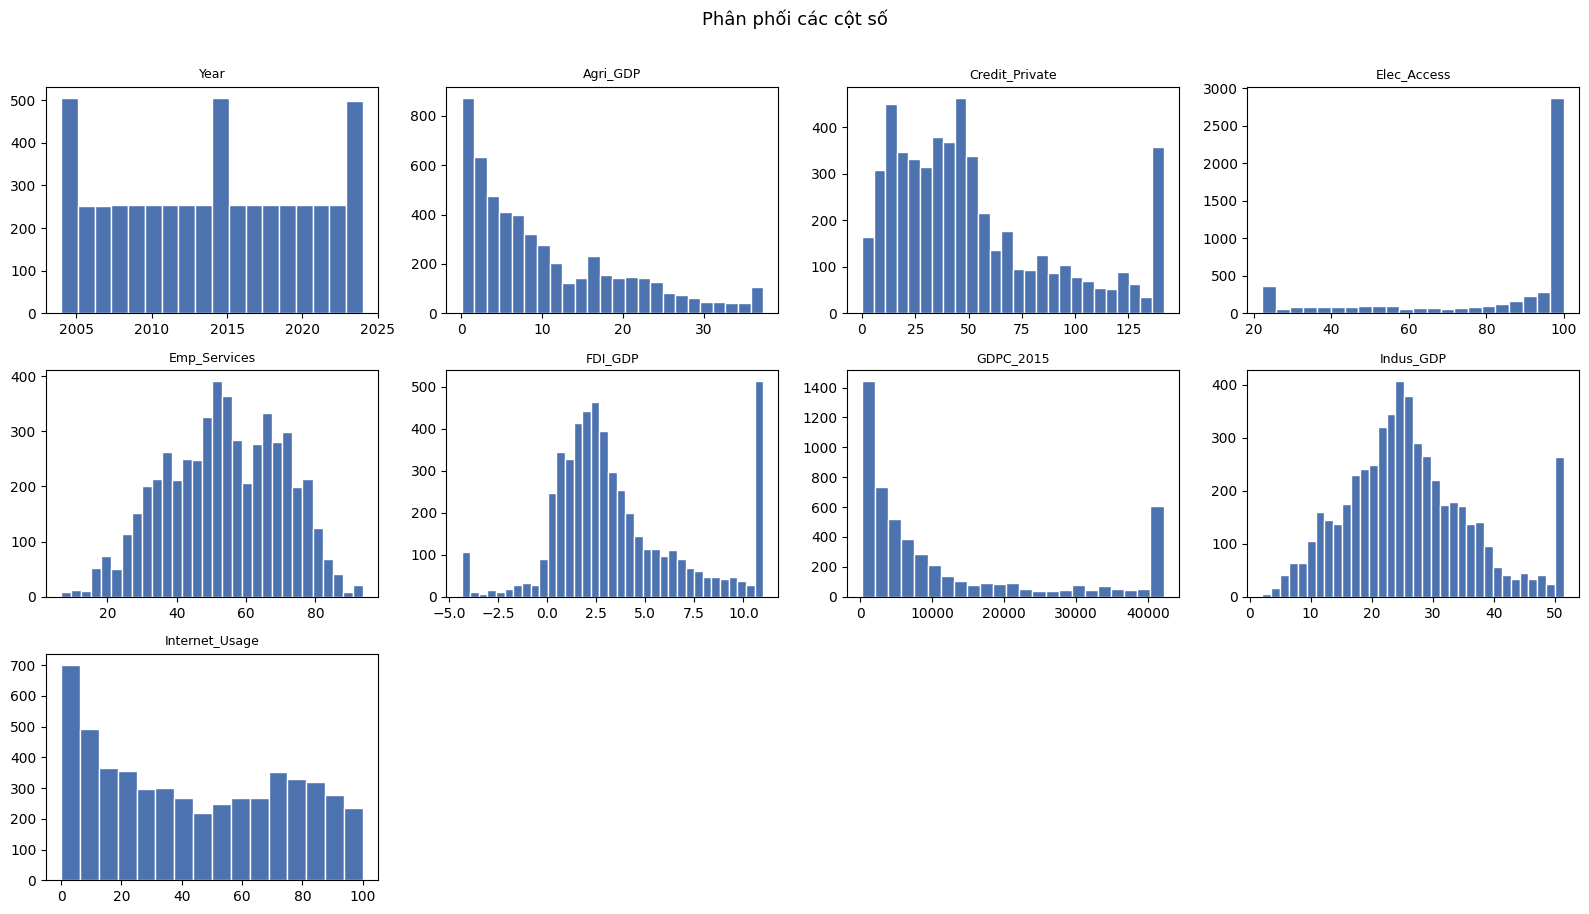

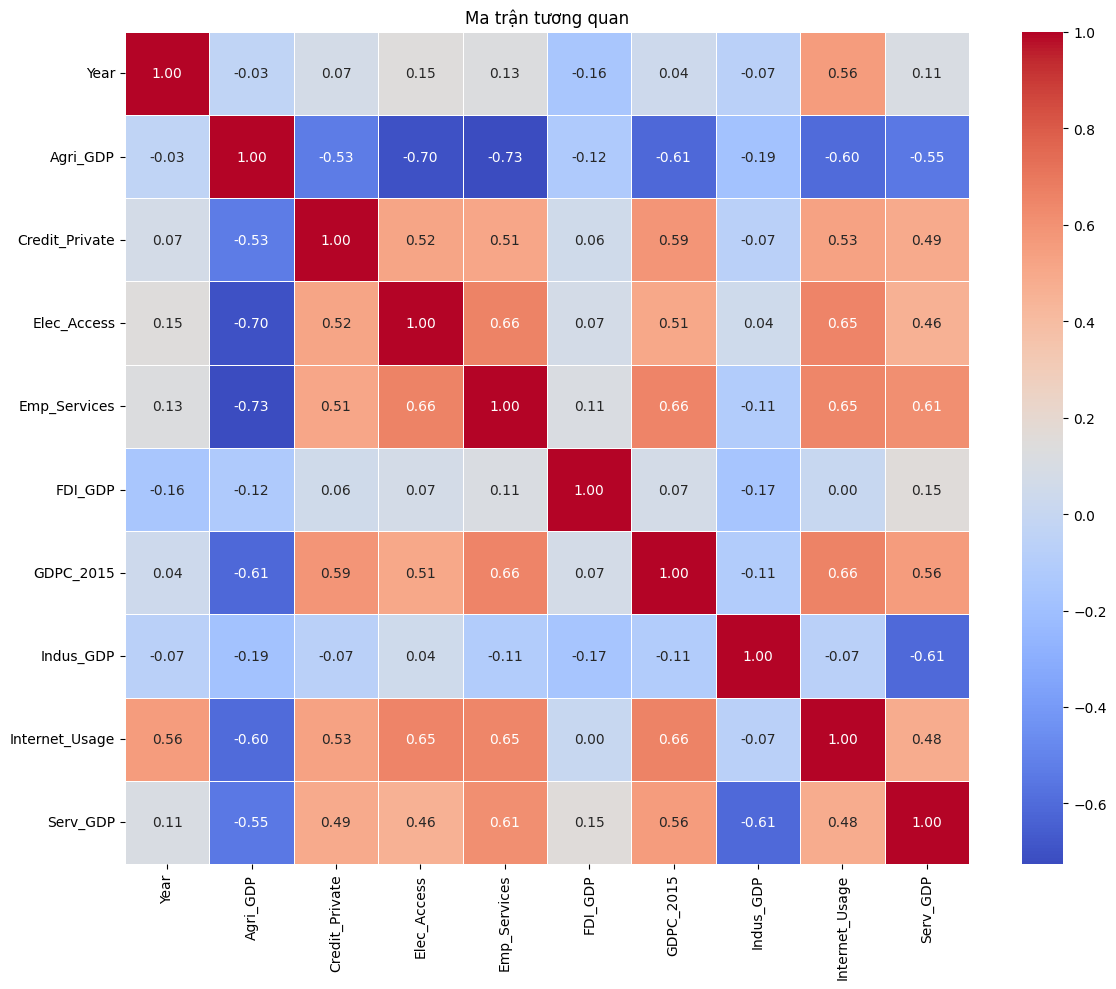

In [32]:
from sklearn.pipeline import Pipeline

wb = pd.read_csv('../data/real data/world_bank_clean.csv')
print(f"Kích thước: {wb.shape}")
print("Thống kê dữ liệu:\n")
display(wb.describe())

wb = wb.drop(columns=['Country'])

# Sử dụng bộ dữ liệu đã được điền khuyết logic để đánh giá hiệu quả imputation, 
# bằng cách thêm thêm dữ liệu thiếu ngẫu nhiên
 
# ════════════════════════════════════════════
# PHÂN TÍCH KHÁM PHÁ (EDA)
# ════════════════════════════════════════════
 
# Phân phối target
target_col = 'Serv_GDP'
print(f"\nPhân phối target '{target_col}':")
print(wb[target_col].value_counts())
 
plt.figure(figsize=(5, 4))
wb[target_col].hist(bins='auto', color='#4C72B0', edgecolor='white')
plt.title('Phân phối target: Serv_GDP')
plt.xlabel('Giá trị')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()
 
# Histogram các cột số
num_cols = wb.select_dtypes('number').drop(columns=[target_col]).columns.tolist()
n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(wb[col].dropna(), bins='auto', color='#4C72B0', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Phân phối các cột số', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()
 
# Ma trận tương quan (chỉ cột số, bỏ lesion_* và missing_* indicator)
core_cols = [c for c in num_cols if not c.startswith('lesion_') and not c.endswith('_missing')]
corr = wb[core_cols + [target_col]].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, fmt='.2f', annot= True, cmap='coolwarm', linewidths=0.5)
plt.title('Ma trận tương quan')
plt.tight_layout()
plt.show()
 
# ════════════════════════════════════════════
# TÁCH FEATURES & TARGET, TRAIN-TEST SPLIT
# ════════════════════════════════════════════
# Dùng KFold cho biến mục tiêu dạng continuous
cv = KFold(n_splits=5) # train/ test: 80/20
reg = RandomForestRegressor(n_estimators=100, random_state=42)

# IterativeImputer – 4 configurations
all_imputers = {
    # IterativeImputer – 4 configurations
    'MICE\nBayesianRidge\nmax_iter=10':  IterativeImputer(estimator=BayesianRidge(),
                                           max_iter=10, random_state=0),
    'MICE\nRandomForest\nmax_iter=10':   IterativeImputer(estimator=RandomForestRegressor(n_estimators=50, random_state=0, max_depth=5),
                                           max_iter=5, random_state=0),
    'MICE\nExtraTrees\nmax_iter=10':     IterativeImputer(estimator=ExtraTreesRegressor(50,random_state=0, max_depth=5),
                                           max_iter=5, random_state=0),
    'MICE\nBayesianRidge\nmax_iter=20':  IterativeImputer(estimator=BayesianRidge(),
                                           max_iter=20, random_state=0),
    'SimpleImputer(mean)': SimpleImputer(strategy='mean'),
    'KNNImputer': KNNImputer(n_neighbors=5, weights='distance')
}

# Display offsets of imputed features and orginal features for each configurations
wb_results = []

# IterativeImputer – 4 configurations
for con, imp in all_imputers.items():
    IterI = mi.missing_imputer(df=wb,fold_method= cv,clf_method= reg,imputer_name= con,imputer_method= imp, is_missing=False, type='regression')
    wb_results.append(IterI)

# Simple Imputer
simp = SimpleImputer(strategy='mean')
SimpI = missing_imputer(df=wb,fold_method= cv,clf_method= reg,imputer_name= 'Simple\nImputer',imputer_method= simp, is_missing=False, type='regression')
wb_results.append(SimpI)

# KNN Imputer
knn = KNNImputer(n_neighbors=5, weights='distance')
KNNI = missing_imputer(df=wb,fold_method= cv,clf_method= reg,imputer_name= 'KNN\nImputer',imputer_method= knn, is_missing=False, type='regression')
wb_results.append(KNNI)

Bảng so sánh sơ bộ (MSE tăng dần)
                        Method name  Avg_NRMSE       MAE        MSE
6                   Simple\nImputer   0.272153  4.724297  44.823461
1   MICE\nRandomForest\nmax_iter=10   0.169004  4.796817  48.604960
0  MICE\nBayesianRidge\nmax_iter=10   0.195927  4.994009  48.960454
2     MICE\nExtraTrees\nmax_iter=10   0.168496  4.787774  48.966236
4               SimpleImputer(mean)   0.274455  4.938983  50.201034
3  MICE\nBayesianRidge\nmax_iter=20   0.201290  5.061839  51.329950
5                        KNNImputer   0.255041  5.282801  55.938650
7                      KNN\nImputer   0.251380  5.294131  56.410818


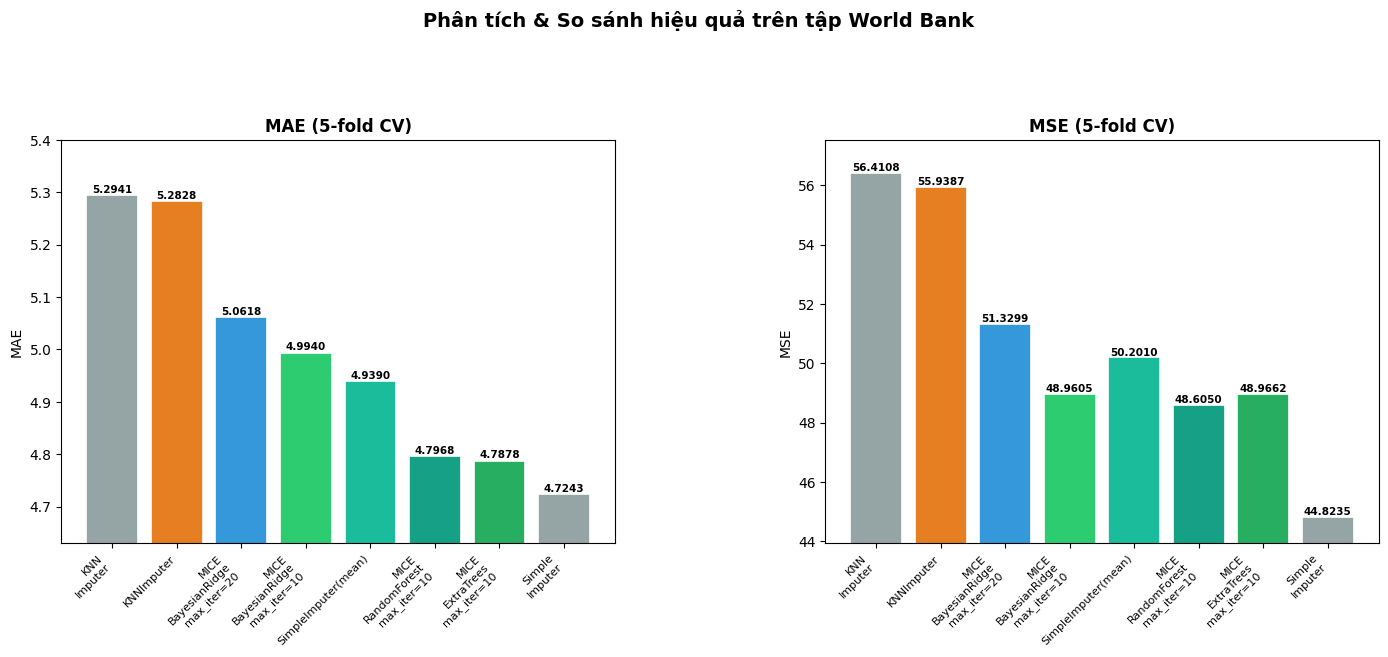

In [33]:
# Bar-charts
wb_results = pd.DataFrame(wb_results)
print('Bảng so sánh sơ bộ (MSE tăng dần)')
print(wb_results.sort_values('MSE'))
wb_results = pd.DataFrame(wb_results).sort_values('MAE', ascending=False)
fig = plt.figure(figsize=(17, 13))
fig.suptitle("Phân tích & So sánh hiệu quả trên tập World Bank",
             fontsize=14, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.48, wspace=0.38)

# MAE
ax1 = fig.add_subplot(gs[0, 0])
all_accs = wb_results['MAE']
colors_all = ['#95a5a6','#e67e22','#3498db','#2ecc71','#1abc9c','#16a085','#27ae60']
bars1 = ax1.bar(range(len(wb_results['Method name'])), all_accs,
                color=colors_all, edgecolor='white', linewidth=1.2)

# Thiết lập trục X
ax1.set_xticks(range(len(wb_results['Method name'])))
ax1.set_xticklabels(wb_results['Method name'], fontsize=8, rotation=45, ha='right') # Xoay chữ 45 độ

# Thiết lập giới hạn trục Y cho dễ quan sát sự khác biệt
ax1.set_ylim(min(all_accs)*0.98, max(all_accs)*1.02)

ax1.set_title("MAE (5-fold CV)", fontweight='bold')
ax1.set_ylabel("MAE")
for bar, v in zip(bars1, all_accs):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    
# MSE
ax2 = fig.add_subplot(gs[0, 1])
all_accs = wb_results['MSE']
colors_all = ['#95a5a6','#e67e22','#3498db','#2ecc71','#1abc9c','#16a085','#27ae60']
bars2 = ax2.bar(range(len(wb_results['Method name'])), all_accs,
                color=colors_all, edgecolor='white', linewidth=1.2)

# Thiết lập trục X
ax2.set_xticks(range(len(wb_results['Method name'])))
ax2.set_xticklabels(wb_results['Method name'], fontsize=8, rotation=45, ha='right') # Xoay chữ 45 độ

# Thiết lập giới hạn trục Y cho dễ quan sát sự khác biệt
ax2.set_ylim(min(all_accs)*0.98, max(all_accs)*1.02)

ax2.set_title("MSE (5-fold CV)", fontweight='bold')
ax2.set_ylabel("MSE")
for bar, v in zip(bars2, all_accs):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')